## Phiên bản được viết bằng Numba

In [1]:
import os
import sys
from pathlib import Path

In [2]:
current_path = Path().resolve()
while current_path.name != "APP-project":
    if current_path.parent == current_path:
        raise FileNotFoundError("❌ Không tìm thấy thư mục gốc 'APP-project'")
    current_path = current_path.parent

os.chdir(current_path)
# print(f"📂 Project root set to: {current_path}")

In [3]:
# !"D:\Download\Downloads\python.exe" -m pip install -r requirements_python311.txt

In [4]:
sys.path.append('Src')
from Src import func as func

import numpy as np
import matplotlib.pyplot as plt

from numpy.lib.stride_tricks import as_strided

import random
import math
import time

from numba import cuda, float32

import warnings
warnings.filterwarnings('ignore')

In [5]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Wed_Apr_17_19:36:51_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.5, V12.5.40
Build cuda_12.5.r12.5/compiler.34177558_0


In [6]:
!ptxas --version

ptxas: NVIDIA (R) Ptx optimizing assembler
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Wed_Apr_17_19:33:34_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.5, V12.5.40
Build cuda_12.5.r12.5/compiler.34177558_0


### Các kernel bổ trợ

In [22]:
@cuda.jit
def matmul_kernel(A, B, C):
    row, col = cuda.grid(2)
    if row < C.shape[0] and col < C.shape[1]:
        tmp = 0.0
        for k in range(A.shape[1]):
            tmp += A[row, k] * B[k, col]
        C[row, col] = tmp

@cuda.jit
def add_bias_kernel(out, bias):
    idx = cuda.grid(1)
    N, H, W, C = out.shape
    total = N * H * W * C
    if idx < total:
        n = idx // (H * W * C)
        hwc = idx % (H * W * C)
        h = hwc // (W * C)
        w = (hwc // C) % W
        c = hwc % C
        out[n, h, w, c] += bias[c]

@cuda.jit
def sum_rows_kernel(input_matrix, output_vector):
    col = cuda.grid(1)
    if col < input_matrix.shape[1]:
        temp = 0.0
        for i in range(input_matrix.shape[0]):
            temp += input_matrix[i, col]
        output_vector[col] = temp

@cuda.jit
def transpose_kernel(input_matrix, output_matrix):
    i, j = cuda.grid(2)
    if i < input_matrix.shape[0] and j < input_matrix.shape[1]:
        output_matrix[j, i] = input_matrix[i, j]

# Utility function to apply transpose on GPU
def transpose_matrix_gpu(matrix):
    input_device = cuda.to_device(np.ascontiguousarray(matrix))
    output_device = cuda.device_array((matrix.shape[1], matrix.shape[0]), dtype=matrix.dtype)

    threadsperblock = (16, 16)
    blockspergrid_x = (matrix.shape[0] + threadsperblock[0] - 1) // threadsperblock[0]
    blockspergrid_y = (matrix.shape[1] + threadsperblock[1] - 1) // threadsperblock[1]
    transpose_kernel[(blockspergrid_x, blockspergrid_y), threadsperblock](input_device, output_device)

    return output_device

### Class Conv2D

#### Hàm bổ trợ

In [20]:
@cuda.jit
def im2col_kernel(padded, ksize, stride, cols, out_h, out_w):
    n, l = cuda.grid(2)
    N, H_p, W_p, C = padded.shape
    k = ksize
    if n < N and l < out_h * out_w:
        row_out = l // out_w
        col_out = l % out_w

        for i in range(k):
            for j in range(k):
                for c in range(C):
                    row_in = row_out * stride + i
                    col_in = col_out * stride + j
                    patch_val = padded[n, row_in, col_in, c]
                    col_idx = i * k * C + j * C + c
                    cols[n, l, col_idx] = patch_val

@cuda.jit
def col2im_kernel(cols, grad_input, ksize, stride, out_h, out_w, pad_h, pad_w):
    n, l = cuda.grid(2)
    N, _, C = cols.shape
    k = ksize
    if n < N and l < out_h * out_w:
        row_out = l // out_w
        col_out = l % out_w
        for i in range(k):
            for j in range(k):
                for c in range(C):
                    row_in = row_out * stride + i
                    col_in = col_out * stride + j
                    col_idx = i * k * C + j * C + c
                    cuda.atomic.add(grad_input, (n, row_in, col_in, c), cols[n, l, col_idx])

In [24]:
class Conv2D_CUDA:
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        limit = 0.1
        self.kernels = np.random.uniform(-limit, limit, 
            (out_channels, kernel_size * kernel_size * in_channels)).astype(np.float32)
        self.biases = np.random.uniform(-limit, limit, out_channels).astype(np.float32)
        self.v_kernels = np.zeros_like(self.kernels)
        self.v_biases = np.zeros_like(self.biases)

    def im2col_cuda(self, input_data):
        N, H, W, C = input_data.shape
        k, s, p = self.kernel_size, self.stride, self.padding
        H_p, W_p = H + 2 * p, W + 2 * p
        out_h = (H_p - k) // s + 1
        out_w = (W_p - k) // s + 1

        padded = np.pad(input_data, ((0, 0), (p, p), (p, p), (0, 0)), mode='constant')
        padded_device = cuda.to_device(np.ascontiguousarray(padded))
        cols_device = cuda.device_array((N, out_h * out_w, k * k * C), dtype=np.float32)

        threadsperblock = (8, 8)
        blockspergrid_x = (N + threadsperblock[0] - 1) // threadsperblock[0]
        blockspergrid_y = (out_h * out_w + threadsperblock[1] - 1) // threadsperblock[1]
        im2col_kernel[(blockspergrid_x, blockspergrid_y), threadsperblock](
            padded_device, k, s, cols_device, out_h, out_w
        )

        return cols_device.copy_to_host(), out_h, out_w

    def col2im_cuda(self, cols, input_shape):
        N, H, W, C = input_shape
        k, s, p = self.kernel_size, self.stride, self.padding
        H_p, W_p = H + 2 * p, W + 2 * p
        out_h = (H_p - k) // s + 1
        out_w = (W_p - k) // s + 1

        cols_device = cuda.to_device(np.ascontiguousarray(cols))
        grad_input_device = cuda.device_array((N, H_p, W_p, C), dtype=np.float32)

        threadsperblock = (8, 8)
        blockspergrid_x = (N + threadsperblock[0] - 1) // threadsperblock[0]
        blockspergrid_y = (out_h * out_w + threadsperblock[1] - 1) // threadsperblock[1]
        col2im_kernel[(blockspergrid_x, blockspergrid_y), threadsperblock](
            cols_device, grad_input_device, k, s, out_h, out_w, p, p
        )

        padded_result = grad_input_device.copy_to_host()
        return padded_result[:, p:p+H, p:p+W, :] if p > 0 else padded_result

    def forward(self, input_data):
        self.input_data = input_data
        self.cols, self.out_h, self.out_w = self.im2col_cuda(np.ascontiguousarray(input_data))
        N, L, K = self.cols.shape

        d_cols = cuda.to_device(np.ascontiguousarray(self.cols.reshape(-1, K)))
        d_kernels = transpose_matrix_gpu(self.kernels)
        d_output = cuda.device_array((N * L, self.out_channels), dtype=np.float32)

        threads_per_block = (16, 16)
        blocks_x = (N * L + threads_per_block[0] - 1) // threads_per_block[0]
        blocks_y = (self.out_channels + threads_per_block[1] - 1) // threads_per_block[1]
        matmul_kernel[(blocks_x, blocks_y), threads_per_block](d_cols, d_kernels, d_output)

        result = d_output.copy_to_host().reshape(N, self.out_h, self.out_w, self.out_channels)
        d_result = cuda.to_device(np.ascontiguousarray(result))
        total = N * self.out_h * self.out_w * self.out_channels
        threads = 256
        blocks = (total + threads - 1) // threads
        add_bias_kernel[blocks, threads](d_result, self.biases)

        return d_result.copy_to_host()

    def backward(self, grad_output):
        N, out_h, out_w, out_c = grad_output.shape
        L = out_h * out_w
        grad_output_reshaped = grad_output.reshape(N * L, out_c)
        cols_reshaped = self.cols.reshape(N * L, -1)

        # Gradient kernels
        d_grad_output = cuda.to_device(np.ascontiguousarray(grad_output_reshaped))
        d_cols = cuda.to_device(np.ascontiguousarray(cols_reshaped))
        d_grad_kernels = cuda.device_array((out_c, cols_reshaped.shape[1]), dtype=np.float32)

        threads_per_block = (16, 16)
        blocks_x = (out_c + threads_per_block[0] - 1) // threads_per_block[0]
        blocks_y = (cols_reshaped.shape[1] + threads_per_block[1] - 1) // threads_per_block[1]
        matmul_kernel[(blocks_x, blocks_y), threads_per_block](d_grad_output.T, d_cols, d_grad_kernels)
        self.grad_kernels = d_grad_kernels.copy_to_host().reshape(self.kernels.shape)

        # Gradient biases
        d_grad_biases = cuda.device_array(out_c, dtype=np.float32)
        threads = 256
        blocks = (out_c + threads - 1) // threads
        sum_rows_kernel[blocks, threads](d_grad_output, d_grad_biases)
        self.grad_biases = d_grad_biases.copy_to_host()

        # Gradient w.r.t input
        d_kernels_T = transpose_matrix_gpu(self.kernels)
        d_grad_cols = cuda.device_array((N * L, self.kernels.shape[1]), dtype=np.float32)
        matmul_kernel[(blocks_x, blocks_y), threads_per_block](d_grad_output, d_kernels_T, d_grad_cols)
        grad_cols = d_grad_cols.copy_to_host().reshape(N, L, -1)
        grad_input = self.col2im_cuda(grad_cols, self.input_data.shape)
        return grad_input

    def step(self, lr, momentum):
        self.v_kernels = momentum * self.v_kernels - lr * self.grad_kernels
        self.v_biases = momentum * self.v_biases - lr * self.grad_biases
        self.kernels += self.v_kernels
        self.biases += self.v_biases

#### Test

In [36]:
# Lấy 2 ảnh đầu từ CIFAR-10
X_batch = X_train[:2]  # (2, 32, 32, 3)

# Khởi tạo Conv2D_CUDA: 3 input channels (RGB), 8 output filters
conv = Conv2D_CUDA(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1)

# Gọi forward để test
output = conv.forward(X_batch)

# In kết quả
print("✅ Test Conv2D_CUDA với batch nhỏ thành công.")
print("Input shape :", X_batch.shape)
print("Output shape:", output.shape)
print("Sample output (batch 0, pixel 0,0):", output[0, 0, 0])

✅ Test Conv2D_CUDA với batch nhỏ thành công.
Input shape : (2, 32, 32, 3)
Output shape: (2, 32, 32, 8)
Sample output (batch 0, pixel 0,0): [ 0.05778217 -0.07533114  0.09199853  0.11454438 -0.02201691  0.10049492
 -0.04052458 -0.013725  ]


### Class ReLU

#### Forward

In [37]:
@cuda.jit
def relu_forward_kernel(input_tensor, output_tensor):
    idx = cuda.grid(1)
    if idx >= input_tensor.size:
        return

    if input_tensor.flat[idx] > 0:
        output_tensor.flat[idx] = input_tensor.flat[idx]
    else:
        output_tensor.flat[idx] = 0

#### Backward

In [38]:
@cuda.jit
def relu_backward_kernel(input_tensor, grad_output, grad_input):
    idx = cuda.grid(1)
    if idx >= input_tensor.size:
        return

    grad_input.flat[idx] = grad_output.flat[idx] if input_tensor.flat[idx] > 0 else 0.0

#### Class ReLU_CUDA

In [39]:
class ReLU_CUDA:
    def __init__(self):
        self.input_device = None  # Lưu lại input trên device

    def forward(self, x):
        d_input = cuda.to_device(np.ascontiguousarray(x))
        d_output = cuda.device_array_like(x)

        threads = 256
        blocks = (x.size + threads - 1) // threads
        relu_forward_kernel[blocks, threads](d_input, d_output)

        self.input_device = d_input  # Lưu lại cho backward
        return d_output.copy_to_host()

    def backward(self, grad_output):
        d_grad_output = cuda.to_device(np.ascontiguousarray(grad_output))
        d_grad_input = cuda.device_array_like(grad_output)

        threads = 256
        blocks = (grad_output.size + threads - 1) // threads
        relu_backward_kernel[blocks, threads](self.input_device, d_grad_output, d_grad_input)

        return d_grad_input.copy_to_host()

#### Test

In [40]:
# # 1. Chuẩn bị batch dữ liệu đầu vào
# X_batch = X_train[:2]  # (2, 32, 32, 3)

# # 2. Khởi tạo lớp Conv2D và ReLU
# conv = Conv2D_CUDA(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1)
# relu = ReLU_CUDA()

# # 3. Forward Conv
# conv_out = conv.forward(X_batch)
# print("✅ Conv2D forward done. Output shape:", conv_out.shape)

# # 4. Forward ReLU
# relu_out = relu.forward(conv_out)
# print("✅ ReLU forward done. Output shape :", relu_out.shape)

# # 5. Tạo gradient ngẫu nhiên từ lớp tiếp theo
# grad_next = np.random.randn(*relu_out.shape).astype(np.float32)

# # 6. Backward ReLU
# grad_relu = relu.backward(grad_next)
# print("✅ ReLU backward done. Grad shape   :", grad_relu.shape)

# # 7. Backward Conv2D
# grad_input = conv.backward(grad_relu)
# print("✅ Conv2D backward done. Grad input shape:", grad_input.shape)

# # 8. Kiểm tra một số giá trị
# print("Sample grad_input[0, 0, 0] =", grad_input[0, 0, 0])

✅ Conv2D forward done. Output shape: (2, 32, 32, 8)
✅ ReLU forward done. Output shape : (2, 32, 32, 8)
✅ ReLU backward done. Grad shape   : (2, 32, 32, 8)
✅ Conv2D backward done. Grad input shape: (2, 32, 32, 3)
Sample grad_input[0, 0, 0] = [0.8387819  0.16723295 0.2602003 ]


### Class MaxPool2D

#### Forward

In [43]:
@cuda.jit
def maxpool2d_forward_kernel(input_tensor, output_tensor, indices, ksize, stride, H_out, W_out):
    idx = cuda.grid(1)
    N, H, W, C = input_tensor.shape
    total = N * H_out * W_out * C
    if idx >= total:
        return

    n = idx // (H_out * W_out * C)
    h_out = (idx % (H_out * W_out * C)) // (W_out * C)
    w_out = (idx % (W_out * C)) // C
    c = idx % C

    h_start = h_out * stride
    w_start = w_out * stride

    max_val = -1e10
    max_idx = 0
    for i in range(ksize):
        for j in range(ksize):
            h = h_start + i
            w = w_start + j
            if h < H and w < W:
                val = input_tensor[n, h, w, c]
                if val > max_val:
                    max_val = val
                    max_idx = i * ksize + j

    output_tensor[n, h_out, w_out, c] = max_val
    indices[n, h_out, w_out, c] = max_idx

#### Backward

In [44]:
@cuda.jit
def maxpool2d_backward_kernel(grad_output, indices, grad_input, ksize, stride, H_out, W_out):
    idx = cuda.grid(1)
    N, H, W, C = grad_input.shape
    total = N * H_out * W_out * C
    if idx >= total:
        return

    n = idx // (H_out * W_out * C)
    h_out = (idx % (H_out * W_out * C)) // (W_out * C)
    w_out = (idx % (W_out * C)) // C
    c = idx % C

    max_idx = int(indices[n, h_out, w_out, c])
    i = max_idx // ksize
    j = max_idx % ksize

    h = h_out * stride + i
    w = w_out * stride + j
    if h < H and w < W:
        grad_input[n, h, w, c] += grad_output[n, h_out, w_out, c]

#### Class

In [41]:
class MaxPool2D_CUDA:
    def __init__(self, kernel_size=2, stride=2):
        self.kernel_size = kernel_size
        self.stride = stride
        self.input_shape = None
        self.d_indices = None

    def forward(self, x):
        N, H, W, C = x.shape
        k, s = self.kernel_size, self.stride
        H_out = (H - k) // s + 1
        W_out = (W - k) // s + 1

        self.input_shape = x.shape

        d_input = cuda.to_device(np.ascontiguousarray(x))
        d_output = cuda.device_array((N, H_out, W_out, C), dtype=np.float32)
        self.d_indices = cuda.device_array((N, H_out, W_out, C), dtype=np.int32)

        threads = 256
        blocks = (N * H_out * W_out * C + threads - 1) // threads

        maxpool2d_forward_kernel[blocks, threads](
            d_input, d_output, self.d_indices, k, s, H_out, W_out
        )

        return d_output.copy_to_host()

    def backward(self, grad_output):
        N, H, W, C = self.input_shape
        k, s = self.kernel_size, self.stride
        H_out, W_out = grad_output.shape[1:3]

        d_grad_output = cuda.to_device(np.ascontiguousarray(grad_output))
        d_grad_input = cuda.device_array((N, H, W, C), dtype=np.float32)

        threads = 256
        blocks = (N * H_out * W_out * C + threads - 1) // threads

        maxpool2d_backward_kernel[blocks, threads](
            d_grad_output, self.d_indices, d_grad_input, k, s, H_out, W_out
        )

        return d_grad_input.copy_to_host()

#### Test

In [45]:
# # --- Input ---
# X_batch = X_train[:2]  # (2, 32, 32, 3)

# # --- Layers ---
# conv = Conv2D_CUDA(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1)
# relu = ReLU_CUDA()
# pool = MaxPool2D_CUDA(kernel_size=2, stride=2)

# # --- FORWARD PASS ---
# x1 = conv.forward(X_batch)            # Conv
# print("✅ Conv output:", x1.shape)

# x2 = relu.forward(x1)                 # ReLU
# print("✅ ReLU output:", x2.shape)

# x3 = pool.forward(x2)                 # MaxPool
# print("✅ MaxPool output:", x3.shape)

# # --- BACKWARD PASS ---
# grad_next = np.random.randn(*x3.shape).astype(np.float32)  # giả lập gradient ngẫu nhiên

# g3 = pool.backward(grad_next)
# print("🔁 Backward MaxPool done, shape:", g3.shape)

# g2 = relu.backward(g3)
# print("🔁 Backward ReLU done, shape:", g2.shape)

# g1 = conv.backward(g2)
# print("🔁 Backward Conv done, shape:", g1.shape)

# # --- Kiểm tra ---
# print("🎯 Sample grad_input[0, 0, 0] =", g1[0, 0, 0])

✅ Conv output: (2, 32, 32, 8)
✅ ReLU output: (2, 32, 32, 8)
✅ MaxPool output: (2, 16, 16, 8)
🔁 Backward MaxPool done, shape: (2, 32, 32, 8)
🔁 Backward ReLU done, shape: (2, 32, 32, 8)
🔁 Backward Conv done, shape: (2, 32, 32, 3)
🎯 Sample grad_input[0, 0, 0] = [0.32173654 0.46939975 1.1156111 ]


### Conv Block

In [46]:
class ConvBlock_CUDA:
    def __init__(self, in_channels, out_channels, num_convs=2, padding=1, stride=1):
        self.convs = []
        self.relus = []

        for _ in range(num_convs):
            conv = Conv2D_CUDA(in_channels, out_channels, kernel_size=3, padding=padding, stride=stride)
            relu = ReLU_CUDA()
            self.convs.append(conv)
            self.relus.append(relu)
            in_channels = out_channels  # chuẩn bị cho conv tiếp theo

        self.pool = MaxPool2D_CUDA(kernel_size=2, stride=2)

    def forward(self, input):
        x = input
        for conv, relu in zip(self.convs, self.relus):
            x = conv.forward(x)
            x = relu.forward(x)
        x = self.pool.forward(x)
        return x

    def backward(self, d_out):
        d_out = self.pool.backward(d_out)
        for conv, relu in zip(reversed(self.convs), reversed(self.relus)):
            d_out = relu.backward(d_out)
            d_out = conv.backward(d_out)
        return d_out

    def step(self, learning_rate, momentum=0.9):
        for conv in self.convs:
            conv.step(learning_rate, momentum)

#### Test

In [22]:
# block = ConvBlock_CUDA(3, 64, num_convs=2)
# x = np.random.rand(1, 32, 32, 3).astype(np.float32)
# out = block.forward(x)
# print(out.shape)  # expect (1, 16, 16, 64)

(1, 16, 16, 64)


### Class Flatten

In [48]:
@cuda.jit
def flatten_forward_kernel(input_tensor, output_tensor):
    idx = cuda.grid(1)
    if idx >= output_tensor.size:
        return
    N, H, W, C = input_tensor.shape
    n = idx // (H * W * C)
    hwc = idx % (H * W * C)
    output_tensor[n, hwc] = input_tensor[n, hwc // (W * C), (hwc // C) % W, hwc % C]

@cuda.jit
def flatten_backward_kernel(grad_output, grad_input):
    idx = cuda.grid(1)
    if idx >= grad_output.size:
        return
    N, H, W, C = grad_input.shape
    n = idx // (H * W * C)
    hwc = idx % (H * W * C)
    grad_input[n, hwc // (W * C), (hwc // C) % W, hwc % C] = grad_output[n, hwc]

class Flatten_CUDA:
    def __init__(self):
        self.input_shape = None

    def forward(self, input):
        self.input_shape = input.shape
        N, H, W, C = self.input_shape
        d_input = cuda.to_device(np.ascontiguousarray(input))
        d_output = cuda.device_array((N, H * W * C), dtype=np.float32)

        threads = 256
        blocks = (N * H * W * C + threads - 1) // threads
        flatten_forward_kernel[blocks, threads](d_input, d_output)

        return d_output.copy_to_host()

    def backward(self, grad_output):
        N, H, W, C = self.input_shape
        d_grad_output = cuda.to_device(np.ascontiguousarray(grad_output))
        d_grad_input = cuda.device_array((N, H, W, C), dtype=np.float32)

        threads = 256
        blocks = (N * H * W * C + threads - 1) // threads
        flatten_backward_kernel[blocks, threads](d_grad_output, d_grad_input)

        return d_grad_input.copy_to_host()

In [55]:
# --- Khởi tạo dữ liệu ---
X_batch = X_train[:2]  # (2, 32, 32, 3)

# --- Khởi tạo lớp Flatten ---
flatten = Flatten_CUDA()

# --- Forward ---
out = flatten.forward(X_batch)
print("✅ Flatten forward done.")
print("Input shape :", X_batch.shape)
print("Output shape:", out.shape)

# --- Tạo gradient ngẫu nhiên để test backward ---
grad_out = np.random.randn(*out.shape).astype(np.float32)

# --- Backward ---
grad_input = flatten.backward(grad_out)
print("✅ Flatten backward done.")
print("Grad input shape:", grad_input.shape)

# --- Kiểm tra khôi phục đúng shape ---
print("🎯 Sample grad_input[0, 0, 0] =", grad_input[0, 0, 0])

✅ Flatten forward done.
Input shape : (2, 32, 32, 3)
Output shape: (2, 3072)
✅ Flatten backward done.
Grad input shape: (2, 32, 32, 3)
🎯 Sample grad_input[0, 0, 0] = [-0.5963214  1.1500291 -0.9663985]


### Class Fully Connected Layer

#### Forward

In [71]:
@cuda.jit
def fc_forward_kernel(input_vec, weights, bias, output):
    i = cuda.grid(1)
    if i < weights.shape[1]:  # output dim
        tmp = 0.
        for j in range(weights.shape[0]):  # input dim
            tmp += input_vec[j] * weights[j, i]
        output[i] = tmp + bias[i]

#### Backward

In [25]:
@cuda.jit
def fc_backward_kernel(grad_output, weights, grad_input):
    i = cuda.grid(1)
    if i < weights.shape[0]:  # input dim
        tmp = 0.
        for j in range(weights.shape[1]):
            tmp += grad_output[j] * weights[i, j]
        grad_input[i] = tmp

#### Class

In [127]:
@cuda.jit
def add_bias_fc_kernel(out, bias):
    idx = cuda.grid(1)
    N, O = out.shape
    if idx < N * O:
        n = idx // O
        o = idx % O
        out[n, o] += bias[o]

class FullyConnected_CUDA:
    def __init__(self, in_dim, out_dim):
        limit = 0.01
        self.W = np.random.uniform(-limit, limit, (in_dim, out_dim)).astype(np.float32)
        self.b = np.random.uniform(-limit, limit, out_dim).astype(np.float32)
        self.v_W = np.zeros_like(self.W)
        self.v_b = np.zeros_like(self.b)

    def forward(self, x):  # x shape: (N, in_dim) or (in_dim,)
        self.input = x.astype(np.float32)
        if self.input.ndim == 1:
            self.input = self.input[None, :]  # reshape (D,) → (1, D)

        N, D = self.input.shape
        d_input = cuda.to_device(np.ascontiguousarray(self.input))
        d_W = cuda.to_device(np.ascontiguousarray(self.W))
        d_out = cuda.device_array((N, self.W.shape[1]), dtype=np.float32)

        # matmul: (N, D) x (D, out_dim)
        threads = (16, 16)
        blocks_x = (N + threads[0] - 1) // threads[0]
        blocks_y = (self.W.shape[1] + threads[1] - 1) // threads[1]
        matmul_kernel[(blocks_x, blocks_y), threads](d_input, d_W, d_out)

        # add bias (N, out_dim)
        d_bias = cuda.to_device(np.ascontiguousarray(self.b))
        threads_bias = 256
        blocks_bias = (N * self.b.shape[0] + threads_bias - 1) // threads_bias
        add_bias_fc_kernel[blocks_bias, threads_bias](d_out, d_bias)

        return d_out.copy_to_host().reshape((-1,) if x.ndim == 1 else (N, self.W.shape[1]))

    def backward(self, grad_output):  # grad_output: (N, out_dim)
        N = grad_output.shape[0]
        d_input_T = transpose_matrix_gpu(self.input)  # shape: (D, N)
        d_grad_output = cuda.to_device(np.ascontiguousarray(grad_output))
        d_grad_W = cuda.device_array_like(self.W)

        # grad_W = input.T @ grad_output
        threads = (16, 16)
        blocks_x = (self.W.shape[0] + threads[0] - 1) // threads[0]
        blocks_y = (self.W.shape[1] + threads[1] - 1) // threads[1]
        matmul_kernel[(blocks_x, blocks_y), threads](d_input_T, d_grad_output, d_grad_W)
        self.grad_W = d_grad_W.copy_to_host()

        # grad_b = sum_rows(grad_output)
        d_grad_b = cuda.device_array(self.b.shape, dtype=np.float32)
        threads_b = 256
        blocks_b = (self.b.shape[0] + threads_b - 1) // threads_b
        sum_rows_kernel[blocks_b, threads_b](d_grad_output, d_grad_b)
        self.grad_b = d_grad_b.copy_to_host()

        # grad_input = grad_output @ W.T
        d_W_T = transpose_matrix_gpu(self.W)
        d_grad_input = cuda.device_array((N, self.W.shape[0]), dtype=np.float32)
        blocks_x2 = (N + threads[0] - 1) // threads[0]
        blocks_y2 = (self.W.shape[0] + threads[1] - 1) // threads[1]
        matmul_kernel[(blocks_x2, blocks_y2), threads](d_grad_output, d_W_T, d_grad_input)

        return d_grad_input.copy_to_host()

    def step(self, learning_rate, momentum=0.9):
        self.v_W = momentum * self.v_W - learning_rate * self.grad_W
        self.v_b = momentum * self.v_b - learning_rate * self.grad_b
        self.W += self.v_W
        self.b += self.v_b

#### Test

In [60]:
# # 1. Chuẩn bị dữ liệu
# X_batch = X_train[:2]  # (2, 32, 32, 3)

# # 2. Flatten
# flatten = Flatten_CUDA()
# x_flat = flatten.forward(X_batch)
# print("✅ Flatten done. Shape:", x_flat.shape)  # (2, 3072)

# # 3. FC layer
# fc = FullyConnected_CUDA(in_dim=x_flat.shape[1], out_dim=10)
# fc_out = fc.forward(x_flat)
# print("✅ FC forward done. Output shape:", fc_out.shape)  # (2, 10)

# # 4. Tạo grad_output giả lập
# grad_fc = np.random.randn(*fc_out.shape).astype(np.float32)

# # 5. Backward
# grad_flat = fc.backward(grad_fc)
# x_grad = flatten.backward(grad_flat)
# print("✅ Backward done.")
# print("Final grad_input shape (should match input):", x_grad.shape)

# # 6. Kiểm tra một phần tử
# print("🎯 Sample grad_input[0, 0, 0] =", x_grad[0, 0, 0])

✅ Flatten done. Shape: (2, 3072)
✅ FC forward done. Output shape: (2, 10)
✅ Backward done.
Final grad_input shape (should match input): (2, 32, 32, 3)
🎯 Sample grad_input[0, 0, 0] = [-0.02530189 -0.00361954  0.00909261]


### Class ReLU cho vector

#### Forward

In [73]:
@cuda.jit
def relu_vector_forward_kernel(x, y, mask):
    i = cuda.grid(1)
    if i < x.shape[0]:  # đúng cách
        val = x[i]
        if val > 0:
            y[i] = val
            mask[i] = 1.0
        else:
            y[i] = 0.0
            mask[i] = 0.0

#### Backward

In [74]:
@cuda.jit
def relu_vector_backward_kernel(grad_output, mask, grad_input):
    i = cuda.grid(1)
    if i < grad_output.shape[0]: 
        grad_input[i] = grad_output[i] * mask[i]

#### Class

In [128]:
class ReLUVector_CUDA:
    def __init__(self):
        self.mask = None  # Giữ trên GPU
        self.original_shape = None

    def forward(self, x):
        x = x.astype(np.float32)
        flatten_input = x.reshape(-1)  # ép về 1D để kernel dễ xử lý
        d_x = cuda.to_device(flatten_input)
        d_y = cuda.device_array_like(d_x)
        self.mask = cuda.device_array_like(d_x)

        threads = 128
        blocks = (flatten_input.size + threads - 1) // threads
        relu_vector_forward_kernel[blocks, threads](d_x, d_y, self.mask)

        return d_y.copy_to_host().reshape(x.shape)  # giữ nguyên shape đầu vào


    def backward(self, grad_output):
        grad_output = grad_output.astype(np.float32).reshape(-1)
        d_grad_output = cuda.to_device(grad_output)
        d_grad_input = cuda.device_array_like(grad_output)

        threads = 128
        blocks = (grad_output.size + threads - 1) // threads
        relu_vector_backward_kernel[blocks, threads](d_grad_output, self.mask, d_grad_input)

        return d_grad_input.copy_to_host().reshape(self.original_shape).copy()

#### Test

In [76]:
# # 1. Tạo đầu vào (2 sample, 10 class)
# x = np.random.randn(2, 10).astype(np.float32)

# # 2. Forward
# relu_vec = ReLUVector_CUDA()
# out = relu_vec.forward(x)
# print("✅ ReLUVector forward done. Shape:", out.shape)

# # 3. Tạo grad giả
# grad = np.ones_like(out, dtype=np.float32)

# # 4. Backward
# grad_input = relu_vec.backward(grad)
# print("✅ ReLUVector backward done. Shape:", grad_input.shape)

# print("🎯 Sample output[0]:", out[0])
# print("🎯 Sample grad_input[0]:", grad_input[0])

✅ ReLUVector forward done. Shape: (20, 1)
✅ ReLUVector backward done. Shape: (20,)
🎯 Sample output[0]: [0.]
🎯 Sample grad_input[0]: 0.0


### Class Softmax + CrossEntropyLoss

In [125]:
@cuda.jit
def softmax_exp_kernel(x, max_val, exp_out):
    i = cuda.grid(1)
    if i < x.shape[0]:
        x_val = float32(x[i])
        max_val_val = float32(max_val[0])
        exp_out[i] = math.exp(x_val - max_val_val)

@cuda.jit
def softmax_sum_kernel(exp_vals, sum_out):
    temp = 0.0
    for i in range(exp_vals.size):
        temp += exp_vals[i]
    sum_out[0] = temp

@cuda.jit
def softmax_kernel(x, max_val, sum_exp, out):
    i = cuda.grid(1)
    if i < x.shape[0]:
        x_val = float32(x[i])
        max_val_val = float32(max_val[0])
        sum_val = float32(sum_exp[0])
        out[i] = math.exp(x_val - max_val_val) / sum_val

class Softmax_CUDA:
    def __init__(self):
        self.output = None
        self.input = None

    def forward(self, x):  # x shape: (N, C)
        x = np.ascontiguousarray(x.astype(np.float32))
        N, C = x.shape
        out = np.zeros_like(x)

        for i in range(N):
            x_i = x[i]
            x_max = np.array([np.max(x_i)], dtype=np.float32)

            d_x = cuda.to_device(x_i)
            d_exp = cuda.device_array_like(d_x)
            d_max = cuda.to_device(x_max)
            d_sum = cuda.device_array((1,), dtype=np.float32)
            d_out = cuda.device_array_like(d_x)

            threads = 128
            blocks = (C + threads - 1) // threads

            softmax_exp_kernel[blocks, threads](d_x, d_max, d_exp)
            softmax_sum_kernel[1, 1](d_exp, d_sum)
            softmax_kernel[blocks, threads](d_x, d_max, d_sum, d_out)

            out[i] = d_out.copy_to_host()

        self.output = out
        return self.output

class CrossEntropyLoss_CUDA:
    def __init__(self):
        self.pred_probs = None
        self.target_onehot = None

    def forward(self, pred_probs, target_onehot):
        self.pred_probs = pred_probs.reshape(target_onehot.shape)
        self.target_onehot = target_onehot.astype(np.float32)
        return -np.sum(self.target_onehot * np.log(self.pred_probs + 1e-12)) / target_onehot.shape[0]

    def backward(self):
        return self.pred_probs - self.target_onehot

In [110]:
x_test = np.array([1.0, 2.0, 3.0, 4.0], dtype=np.float32)
softmax = Softmax_CUDA()
out = softmax.forward(x_test)
print("Softmax output:", out)
print("Tổng:", np.sum(out))  # nên gần 1.0

Softmax output: [0.0320586  0.08714432 0.23688284 0.6439142 ]
Tổng: 1.0


### Class Cấu Trúc

In [78]:
class SimpleCNN_CUDA:
    def __init__(self):
        self.block1 = ConvBlock_CUDA(3, 64, num_convs=2, padding=1)
        self.block2 = ConvBlock_CUDA(64, 128, num_convs=2, padding=1)
        self.block3 = ConvBlock_CUDA(128, 256, num_convs=2, padding=1)

        self.flatten = Flatten_CUDA()
        self.fc1 = FullyConnected_CUDA(256 * 4 * 4, 512)
        self.relu_fc1 = ReLUVector_CUDA()
        self.fc2 = FullyConnected_CUDA(512, 10)
        self.softmax = Softmax_CUDA()

### Train

In [79]:
def train_cuda(model, train_data, train_labels, epochs=10, learning_rate=0.01,
               mb_size=32, momentum=0.9, lr_decay_factor=0.5,
               log_filename="training_log_cuda.csv", detail_log_filename="details_log_cuda.csv"):

    np.random.seed(0)
    best_train_acc = 0
    plateau_count = 0
    patience = 2

    loss_fn = CrossEntropyLoss_CUDA()
    n_samples = train_data.shape[0]
    indices = np.arange(n_samples)

    for epoch in range(epochs):
        start_epoch = time.time()
        total_loss = 0.0
        correct = 0

        conv2d_time = relu_time = maxpool_time = flatten_time = fc_time = softmax_time = 0.0

        np.random.shuffle(indices)
        train_data_shuffled = train_data[indices]
        train_labels_shuffled = train_labels[indices]

        full_batch_count = n_samples // mb_size
        for i in range(full_batch_count):
            start = i * mb_size
            end = start + mb_size
            X_batch = train_data_shuffled[start:end]
            y_batch = train_labels_shuffled[start:end]

            for x, target in zip(X_batch, y_batch):
                x = x[None, ...]
                out = x
                for conv, relu in zip(model.block1.convs, model.block1.relus):
                    t0 = time.time(); out = conv.forward(out); t1 = time.time(); conv2d_time += t1 - t0
                    t0 = time.time(); out = relu.forward(out); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); out = model.block1.pool.forward(out); t1 = time.time(); maxpool_time += t1 - t0

                for conv, relu in zip(model.block2.convs, model.block2.relus):
                    t0 = time.time(); out = conv.forward(out); t1 = time.time(); conv2d_time += t1 - t0
                    t0 = time.time(); out = relu.forward(out); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); out = model.block2.pool.forward(out); t1 = time.time(); maxpool_time += t1 - t0

                for conv, relu in zip(model.block3.convs, model.block3.relus):
                    t0 = time.time(); out = conv.forward(out); t1 = time.time(); conv2d_time += t1 - t0
                    t0 = time.time(); out = relu.forward(out); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); out = model.block3.pool.forward(out); t1 = time.time(); maxpool_time += t1 - t0

                t0 = time.time(); out = model.flatten.forward(out); t1 = time.time(); flatten_time += t1 - t0
                t0 = time.time(); out = model.fc1.forward(out); t1 = time.time(); fc_time += t1 - t0
                t0 = time.time(); out = model.relu_fc1.forward(out); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); out = model.fc2.forward(out); t1 = time.time(); fc_time += t1 - t0
                t0 = time.time(); pred_probs = model.softmax.forward(out); t1 = time.time(); softmax_time += t1 - t0

                loss = loss_fn.forward(pred_probs, target)
                total_loss += loss
                if np.argmax(pred_probs) == np.argmax(target):
                    correct += 1

                t0 = time.time(); grad = loss_fn.backward(); t1 = time.time(); softmax_time += t1 - t0
                t0 = time.time(); grad = model.fc2.backward(grad); t1 = time.time(); fc_time += t1 - t0
                t0 = time.time(); grad = model.relu_fc1.backward(grad); t1 = time.time(); relu_time += t1 - t0
                t0 = time.time(); grad = model.fc1.backward(grad); t1 = time.time(); fc_time += t1 - t0
                t0 = time.time(); grad = model.flatten.backward(grad); t1 = time.time(); flatten_time += t1 - t0

                t0 = time.time(); grad = model.block3.pool.backward(grad); t1 = time.time(); maxpool_time += t1 - t0
                for conv, relu in zip(reversed(model.block3.convs), reversed(model.block3.relus)):
                    t0 = time.time(); grad = relu.backward(grad); t1 = time.time(); relu_time += t1 - t0
                    t0 = time.time(); grad = conv.backward(grad); t1 = time.time(); conv2d_time += t1 - t0

                t0 = time.time(); grad = model.block2.pool.backward(grad); t1 = time.time(); maxpool_time += t1 - t0
                for conv, relu in zip(reversed(model.block2.convs), reversed(model.block2.relus)):
                    t0 = time.time(); grad = relu.backward(grad); t1 = time.time(); relu_time += t1 - t0
                    t0 = time.time(); grad = conv.backward(grad); t1 = time.time(); conv2d_time += t1 - t0

                t0 = time.time(); grad = model.block1.pool.backward(grad); t1 = time.time(); maxpool_time += t1 - t0
                for conv, relu in zip(reversed(model.block1.convs), reversed(model.block1.relus)):
                    t0 = time.time(); grad = relu.backward(grad); t1 = time.time(); relu_time += t1 - t0
                    t0 = time.time(); grad = conv.backward(grad); t1 = time.time(); conv2d_time += t1 - t0

                model.fc2.step(learning_rate, momentum)
                model.fc1.step(learning_rate, momentum)
                model.block3.step(learning_rate, momentum)
                model.block2.step(learning_rate, momentum)
                model.block1.step(learning_rate, momentum)

        end_epoch = time.time()
        epoch_time = end_epoch - start_epoch
        accuracy = correct / (full_batch_count * mb_size)

        func.log_training_details(epoch, epochs, epoch_time, n_samples, total_loss / (full_batch_count * mb_size), accuracy, log_filename)
        func.log_details(f"Epoch_{epoch+1}", mb_size, conv2d_time, relu_time, maxpool_time, flatten_time, fc_time, softmax_time, detail_log_filename)

        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/(full_batch_count * mb_size):.4f} - Acc: {accuracy:.4f} - Time: {epoch_time:.2f}s")
        print(f"    Conv2D: {conv2d_time:.2f}s | ReLU: {relu_time:.2f}s | MaxPool: {maxpool_time:.2f}s | Flatten: {flatten_time:.2f}s | FC: {fc_time:.2f}s | Softmax: {softmax_time:.2f}s\n")

        if epoch == 0:
            best_train_acc = accuracy
            plateau_count = 0
        else:
            if accuracy > best_train_acc:
                best_train_acc = accuracy
                plateau_count = 0
            else:
                plateau_count += 1
                if plateau_count >= patience:
                    learning_rate *= lr_decay_factor
                    plateau_count = 0
                    print(f"⚠️  ReduceLROnPlateau: Learning rate reduced to {learning_rate:.6f}")

In [81]:
def preprocess_cifar10_data():
    X_train, y_train, X_test, y_test = func.load_cifar10_data()

    # Chuyển từ (N, C, H, W) -> (N, H, W, C) và chuẩn hóa về [0, 1]
    X_train = X_train.transpose(0, 2, 3, 1).astype(np.float32) / 255.0
    X_test = X_test.transpose(0, 2, 3, 1).astype(np.float32) / 255.0

    # One-hot encoding cho nhãn
    num_classes = 10
    y_train_onehot = np.eye(num_classes)[y_train]
    y_test_onehot = np.eye(num_classes)[y_test]

    return X_train, y_train_onehot, X_test, y_test_onehot

In [82]:
X_train, y_train_onehot, X_test, y_test_onehot = preprocess_cifar10_data()

In [112]:
# check shape 
print("X_train shape:", X_train.shape)  # (50000, 32, 32, 3)
print("y_train_onehot shape:", y_train_onehot.shape)  # (50000, 10)
print("X_test shape:", X_test.shape)  # (10000, 32, 32, 3)
print("y_test_onehot shape:", y_test_onehot.shape)  # (10000, 10)

X_train shape: (50000, 32, 32, 3)
y_train_onehot shape: (50000, 10)
X_test shape: (10000, 32, 32, 3)
y_test_onehot shape: (10000, 10)


In [122]:
# x = X_train[:2]  # (2, 32, 32, 3)
# y = y_train_onehot[:2]  # (2, 10)

# # Block 1: Conv x2 + ReLU x2 + MaxPool
# conv1_1 = Conv2D_CUDA(3, 64)
# relu1_1 = ReLU_CUDA()
# conv1_2 = Conv2D_CUDA(64, 64)
# relu1_2 = ReLU_CUDA()
# pool1 = MaxPool2D_CUDA()

# out = conv1_1.forward(x)
# out = relu1_1.forward(out)
# out = conv1_2.forward(out)
# out = relu1_2.forward(out)
# out = pool1.forward(out)

# # Block 2
# conv2_1 = Conv2D_CUDA(64, 128)
# relu2_1 = ReLU_CUDA()
# conv2_2 = Conv2D_CUDA(128, 128)
# relu2_2 = ReLU_CUDA()
# pool2 = MaxPool2D_CUDA()

# out = conv2_1.forward(out)
# out = relu2_1.forward(out)
# out = conv2_2.forward(out)
# out = relu2_2.forward(out)
# out = pool2.forward(out)

# # Block 3
# conv3_1 = Conv2D_CUDA(128, 256)
# relu3_1 = ReLU_CUDA()
# conv3_2 = Conv2D_CUDA(256, 256)
# relu3_2 = ReLU_CUDA()
# pool3 = MaxPool2D_CUDA()

# out = conv3_1.forward(out)
# out = relu3_1.forward(out)
# out = conv3_2.forward(out)
# out = relu3_2.forward(out)
# out = pool3.forward(out)

# # Flatten
# flatten = Flatten_CUDA()
# out = flatten.forward(out)

# # Fully Connected
# fc1 = FullyConnected_CUDA(out.shape[1], 512)
# relu_fc1 = ReLUVector_CUDA()
# fc2 = FullyConnected_CUDA(512, 10)
# softmax = Softmax_CUDA()

# out = fc1.forward(out)
# out = relu_fc1.forward(out)
# out = fc2.forward(out)
# out = softmax.forward(out)

# print("✅ Test full forward CNN_CUDA hoàn tất.")
# print("Output shape:", out.shape)
# print("Sample softmax output (image 0):", out[:10])

# loss_fn = CrossEntropyLoss_CUDA()
# pred_probs = out[:2]  # Lấy đúng 2 ảnh đầu tiên tương ứng với batch đầu
# loss = loss_fn.forward(pred_probs, y)
# print("Loss:", loss)

✅ Test full forward CNN_CUDA hoàn tất.
Output shape: (1024, 10)
Sample softmax output (image 0): [[9.7541320e-05 9.7471588e-05 9.8259225e-05 9.6926648e-05 9.7283344e-05
  9.7233547e-05 9.8506913e-05 9.7122989e-05 9.8406308e-05 9.7795455e-05]
 [9.7524477e-05 9.7478747e-05 9.8254437e-05 9.6925411e-05 9.7276759e-05
  9.7213997e-05 9.8540288e-05 9.7144257e-05 9.8412042e-05 9.7766730e-05]
 [9.7525561e-05 9.7478282e-05 9.8254743e-05 9.6925498e-05 9.7277181e-05
  9.7215263e-05 9.8538127e-05 9.7142882e-05 9.8411670e-05 9.7768578e-05]
 [9.7524477e-05 9.7478747e-05 9.8254437e-05 9.6925411e-05 9.7276759e-05
  9.7213997e-05 9.8540288e-05 9.7144257e-05 9.8412042e-05 9.7766730e-05]
 [9.7524477e-05 9.7478747e-05 9.8254437e-05 9.6925411e-05 9.7276759e-05
  9.7213997e-05 9.8540288e-05 9.7144257e-05 9.8412042e-05 9.7766730e-05]
 [9.7525030e-05 9.7478514e-05 9.8254590e-05 9.6925454e-05 9.7276970e-05
  9.7214637e-05 9.8539203e-05 9.7143573e-05 9.8411860e-05 9.7767661e-05]
 [9.7595323e-05 9.7448647e-05 9.8

In [129]:
model = SimpleCNN_CUDA()
train_cuda(
    model,
    X_train[:10],  # train thử 10 mẫu đầu
    y_train_onehot[:10],
    epochs=1,        # train thử 1 epoch
    learning_rate=0.001,
    momentum=0.9,
    lr_decay_factor=0.5,
    mb_size=2,
    log_filename="Data/log/training_log_cuda_ver2_op_10.csv",
    detail_log_filename="Data/log/details_log_cuda_ver2_op_10.csv"
)

TypingError: Failed in cuda mode pipeline (step: nopython frontend)
[1m[1mNo implementation of function Function(<built-in function getitem>) found for signature:
 
 >>> getitem(array(float32, 1d, C), UniTuple(int64 x 2))
 
There are 22 candidate implementations:
[1m  - Of which 20 did not match due to:
  Overload of function 'getitem': File: <numerous>: Line N/A.
    With argument(s): '(array(float32, 1d, C), UniTuple(int64 x 2))':[0m
[1m   No match.[0m
[1m  - Of which 2 did not match due to:
  Overload in function 'GetItemBuffer.generic': File: numba\core\typing\arraydecl.py: Line 209.
    With argument(s): '(array(float32, 1d, C), UniTuple(int64 x 2))':[0m
[1m   Rejected as the implementation raised a specific error:
     NumbaTypeError: [1mcannot index array(float32, 1d, C) with 2 indices: UniTuple(int64 x 2)[0m[0m
  raised from C:\Users\WIN 10\AppData\Roaming\Python\Python311\site-packages\numba\core\typing\arraydecl.py:131
[0m
[0m[1mDuring: typing of intrinsic-call

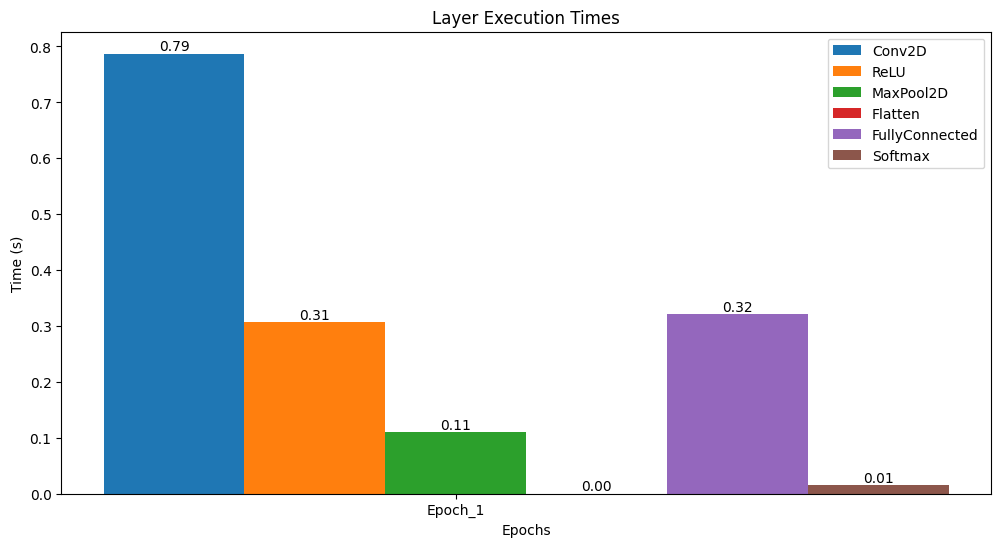

In [68]:
func.plot_details(
    "Data/log/details_log_cuda_ver2_10.csv"
)

In [69]:
model_2 = SimpleCNN_CUDA()
train_cuda(
    model_2,
    X_train,
    y_train_onehot,
    epochs=1,        # train thử 1 epoch
    learning_rate=0.001,
    momentum=0.9,
    lr_decay_factor=0.5,
    mb_size=64,
    log_filename="Data/log/training_log_cuda_ver2_50000.csv",
    detail_log_filename="Data/log/details_log_cuda_ver2_50000.csv"
)

Epoch 1/1 - Loss: 1.6002 - Acc: 0.4150 - Time: 7457.93s
    Conv2D: 3420.57s | ReLU: 1214.66s | MaxPool: 447.65s | Flatten: 0.38s | FC: 1271.87s | Softmax: 54.76s



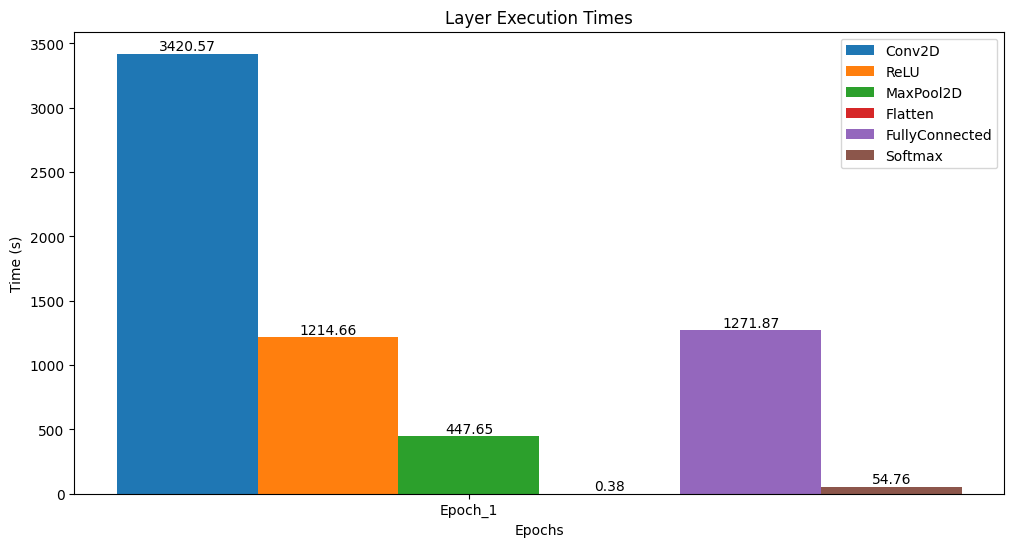

In [70]:
func.plot_details(
    "Data/log/details_log_cuda_ver2_50000.csv"
)

### So sánh 1 epoch giữa Numba và Numba ver 2

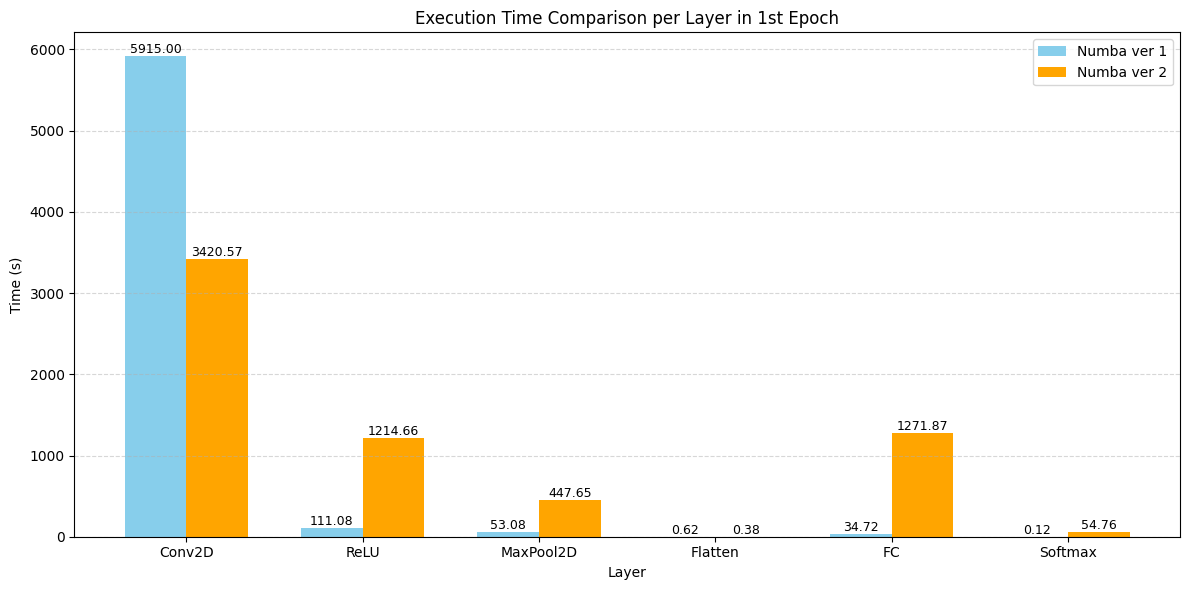

In [77]:
func.plot_compare_details_customized(
    "Data/log/details_log_cuda_50000.csv",
    "Data/log/details_log_cuda_ver2_50000.csv",
    "Numba ver 1",
    "Numba ver 2"
)